# Step 1 — Generate Synthetic Login Dataset

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 5000

login = pd.DataFrame({

"user_id": np.random.randint(1000,5000,n),

"failed_attempts": np.random.randint(0,10,n),

"vpn_usage": np.random.choice([0,1],n),

"new_device_flag": np.random.choice([0,1],n),

"geo_distance": np.random.randint(1,15000,n),

"login_hour": np.random.randint(0,24,n),

"session_duration": np.random.randint(1,120,n)

})

# fraud logic
login["fraud"] = (
(login["failed_attempts"] > 5) |
(login["vpn_usage"] == 1) |
(login["geo_distance"] > 8000) |
(login["new_device_flag"] == 1)
).astype(int)

login.head()

,user_id,failed_attempts,vpn_usage,new_device_flag,geo_distance,login_hour,session_duration,fraud
0,4174,1,1,1,11821,11,12,1
1,4507,1,0,1,6388,2,18,1
2,1860,9,1,1,8974,22,78,1
3,2294,7,0,1,6768,21,10,1
4,2130,1,1,0,567,14,74,1


# Step 2 — Train Fraud Detection Model

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = login.drop("fraud",axis=1)

y = login["fraud"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestClassifier(n_estimators=200)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00       920

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



# Step 3 — Fraud Signal Importance

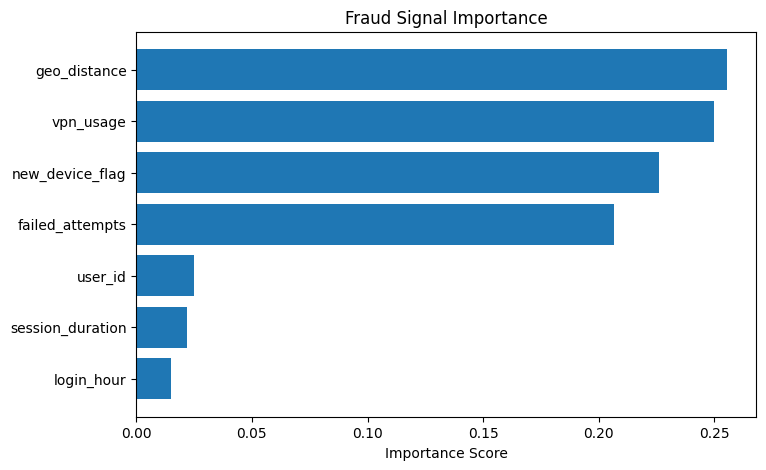

In [3]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

importance_df = pd.DataFrame({
"feature": X.columns,
"importance": importance
}).sort_values("importance")

plt.figure(figsize=(8,5))

plt.barh(
importance_df["feature"],
importance_df["importance"]
)

plt.title("Fraud Signal Importance")

plt.xlabel("Importance Score")

plt.show()